# Object Detection with YOLO
In this notebook, we will use the YOLOv8 model to identify objects in images.

**Learning Objectives**

1. Organize image and label data for training a detection model
2. Fine-tune a pre-trained YOLOv8 model on a custom dataset
3. Generate predictions and extract bounding box coordinates from a trained model

**Import modules**

Begin by importing the modules to be used in this notebook.

In [40]:
# base modules
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import cv2
import shutil
from IPython.display import Video
from sklearn.model_selection import train_test_split
import sys
sys.stderr = open(os.devnull, 'w') # this line is to silence some NNPACK warning on local laptop

## Notebook Set Up
In this notebook, we will be running some training routines on a fairly large model. To support this effort, it is helpful to have a GPU as well as plenty of RAM on your machine. Most laptops do not have this capability, so we will turn to the Google Colab resources for assistance. However, the training process (one cell in this notebook) is the only part that requires these resources. As a result, this notebook is also set up to run on a personal machine with weights that have been fine-tuned for this example. To determine which machine we are on, let's define a home directory:

In [2]:
home_dir = os.path.expanduser('~')

If you are on your personal machine and you used the installation instructions from this "book", then you should be able to import the following modules in your notebook. Otherwise, we will need to install them in our instance of Colab:

In [6]:
if home_dir=='/root':
    os.system('pip install ultralytics')
    os.system('pip install pyyaml')
from ultralytics import YOLO
import yaml

Next up, we will need to have a way to access the data for this notebook including:
- the `aquarium_video.webm` file
- the `labels` directory

This data originates from a Kaggle dataset available [HERE](https://www.kaggle.com/datasets/trainingdatapro/fish-tracking-dataset) that has been pre-processed for this notebook.

If you are running this notebook on your local machine, then you can put these files in whatever location works best for you:

In [7]:
if home_dir!='/root':
    working_dir = os.path.join('..','data','aquarium_data')

If we are on Google Colab, then it is recommended that you put these files in a Google Drive folder and mount your Google Drive on Colab:

In [8]:
if home_dir=='/root':
    from google.colab import drive
    drive.mount('/content/drive')

Then, provide a file path to the folder where you have the necessary files, e.g.

In [9]:
if home_dir=='/root':
    working_dir = '/content/drive/MyDrive/Teaching/MS_285/data/yolo_aquarium_demo'

If everything is set up correctly, you should be able to find the following files:

In [10]:
if 'aquarium_video.webm' in os.listdir(working_dir):
    print('Found aquarium_video.webm successfully!')
else:
    print('Hmmm.... couldn\'t find aquarium_video.webm')


if 'labels' in os.listdir(working_dir):
    print('Found labels successfully!')
else:
    print('Hmmm.... couldn\'t find labels')

Found aquarium_video.webm successfully!
Found labels successfully!


## Fish Detection in Video

Now that the notebook is prepped, we're ready to start on the problem at hand. In this notebook, we are going to build a model to identify fish in some footage captured in an aquarium. Let's have a look at this footage:

In [11]:
display(Video(os.path.join(working_dir,'aquarium_video.webm'), width=600, embed=True))

Of course, this is some toy data, but it does mimic some real data that an ichthyologist might actually collect (e.g. Moss Landing graduate students!).

### Generating training images

To work with this footage for the creation of our model, we're going to need to extract each frame from this movie. Let's do that here:

In [12]:
# make a directory structure for the scenes
if 'images' not in os.listdir(working_dir):
    os.mkdir(os.path.join(working_dir, 'images'))

# extract scenes from the video
cap = cv2.VideoCapture(os.path.join(working_dir,'aquarium_video.webm'))
frame_count = 1
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(os.path.join(working_dir, 'images','{:02d}'.format(frame_count)+'.jpg'), frame)
    frame_count += 1
cap.release()

This block created an image of each frame in the footage. We can take a look at the first one of these scenes as follows:

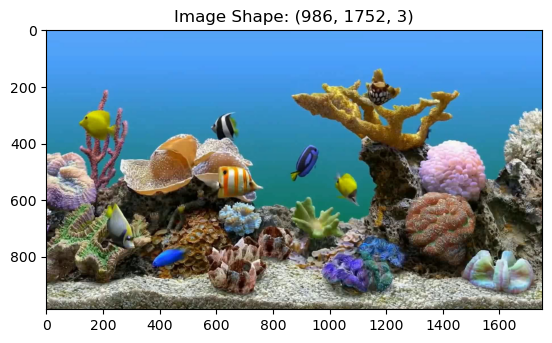

In [13]:
img_path = os.path.join(working_dir, 'images','01.jpg')
image = Image.open(img_path).convert('RGB')
image_array = np.array(image)
plt.imshow(image)
plt.title('Image Shape: '+str(np.shape(image_array)))
plt.show()

### Creating training labels

To build a model that can identify fish in these images, we're going to need some training labels i.e. the locations where the fish are in each image. Once we have a set to train the model, then we can use the model for other unseen footage - but we need to do a little heavy lifting first. Luckily there are some software programs that can help in this process.

Imagine that we have done this pre-processing in a software program and have created a set of files for reach image that look like this:

In [14]:
label_path = os.path.join(working_dir,'labels','01.txt')
labels = np.genfromtxt(label_path, delimiter=' ')
print(labels)

[[          0      0.1039     0.34422     0.07645     0.11075]
 [          0     0.36119     0.34628    0.058128     0.10485]
 [          0     0.38612     0.54674     0.10627      0.1226]
 [          0     0.60533       0.571    0.053014     0.12728]
 [          0     0.14779     0.70423    0.063413     0.17006]
 [          0     0.25289     0.81325    0.076918    0.070943]
 [          0     0.68131      0.2309    0.072557    0.086937]
 [          0     0.76075     0.36645    0.033516    0.059118]
 [          0       0.521     0.47841    0.059623     0.13198]]


In this organization, the second and third columns correspond to the center x and y coordinates of the fish in the image. These coordinates have been normalized by the width and height of the image, so they yield the relative distance within the image. The fourth and fifth columns are the widths and heights of the bounding boxes, again normalized by the image size. Finally, the first column corresponds to the ID of the fish. In this example, all fish are given the ID 0 - we won't worry about the species of the fish for this example - but you could image that these IDs could be used for the different types of fish seen in the footage (e.g. 0 for angel fish, 1 for yellowtail damsel, etc)

We can see how to plot these on the first image. First, make a quick helper function to plot each bounding box:

In [15]:
def plot_bounding_box(ax,image_width, image_height, extent):
    # denormalize the bounding box
    extent[0]*=image_width
    extent[2]*=image_width
    extent[1]*=image_height
    extent[3]*=image_height
    # plot each side of the box
    plt.plot([extent[0]-extent[2]/2, extent[0]+extent[2]/2], [extent[1]-extent[3]/2, extent[1]-extent[3]/2], 'r-')
    plt.plot([extent[0]-extent[2]/2, extent[0]+extent[2]/2], [extent[1]+extent[3]/2, extent[1]+extent[3]/2], 'r-')
    plt.plot([extent[0]-extent[2]/2, extent[0]-extent[2]/2], [extent[1]-extent[3]/2, extent[1]+extent[3]/2], 'r-')
    plt.plot([extent[0]+extent[2]/2, extent[0]+extent[2]/2], [extent[1]-extent[3]/2, extent[1]+extent[3]/2], 'r-')

Then, use the helper function to plot rectangles on the image:

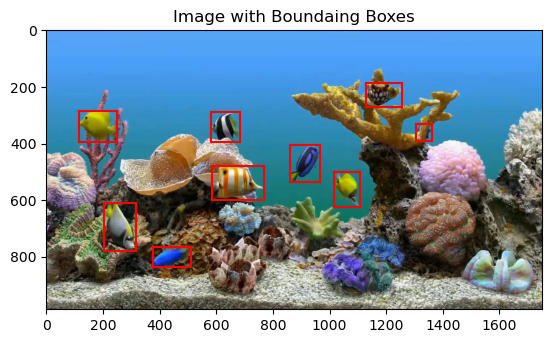

In [16]:
# define the image width and height for scaling
image_width = np.shape(image)[1]
image_height = np.shape(image)[0]

# plot the image
fig = plt.figure()
plt.imshow(image)

# add the bounding boxes on the image
for ll in range(np.shape(labels)[0]):
    extent = np.copy(labels[ll,1:])
    plot_bounding_box(plt.gca(), image_width, image_height, extent)

plt.title('Image with Boundaing Boxes')
plt.show()

As we can see, we have our labels text file contains information about the location of each fish. Now, as efficient scientists, we want to know: *can we use these labeled images to generate a model that can label fish in other similar images?*

## You Only Look Once
YOLO (You Only Look Once) is an object detection model that is formulate to predict bounding boxes and class probabilities directly from an input image using a convolutional neural network. The model is called YOLO because it identifies the bounding box and the classification at the same time unlike two-stage detectors that first generate a region of interest in an image and then classifies it. The YOLO architecture composed has a "backbone" for feature extraction, a "neck" for feature aggregation, and a detection "head" for predicting box coordinates and class labels. YOLO models have undergone significant development in recent years and are used in a lot of applications including , which is autonomous driving, surveillance, and robotics.

### Fine-Tuning a Pre-trained YOLO Model

YOLO models have been trained by other researchers on a wide range of images to give a set of weights that do reasonably-well on a variety of tasks. Here, we would like to take a pre-trained model, and fine-tune it for our purposes. The company [Ultralytics](https://www.ultralytics.com/) has provided some tools to load and fine-tune some of their old pre-trained models. At the time of this writing, the most recent YOLO model is version 26 - we will go way back and take a look at version 8 for our example. Even though this is not the most recent model, it is still quite a large model that can perform well on our fish detection task.

#### Loading a pre-trained model:
To load in some of the pre-trained weights for the YOLOv8 model, we use the following line:

In [20]:
model = YOLO('yolov8s.pt')

If you look at the import lines above, you will see that we imported this model from the `ultralytics` package. However, this package is built on PyTorch! We can take a look at the model architecture just like any other PyTorch model:

In [21]:
# for name, module in model.named_modules():
#     print(name, module)

#### Fine-tuning the model
To fine-tune the model, we will need to provide a set of training and validation (testing) data for the model. To create these sets, let's split up our data into two random sets:

In [22]:
# make some directories for the data
os.makedirs(os.path.join(working_dir,'model','train'), exist_ok=True)
os.makedirs(os.path.join(working_dir,'model','val'), exist_ok=True)

# split the images into training and testing
image_files = sorted(os.listdir(os.path.join(working_dir,'images')))
train_files, val_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=17
)

# copy the training files
for split,file_list in zip(['train','val'], [train_files, val_files]):
    os.makedirs(os.path.join(working_dir,'model',split,'images'), exist_ok=True)
    os.makedirs(os.path.join(working_dir,'model',split,'labels'), exist_ok=True)

    for file_name in file_list:
        shutil.copy(os.path.join(working_dir,'images',file_name),
                    os.path.join(working_dir,'model',split,'images',file_name))

        label_file = file_name.replace(".jpg", ".txt")
        shutil.copy(os.path.join(working_dir,'labels',label_file),
                    os.path.join(working_dir,'model',split,'labels',label_file))

Next, we'll make a configuration file for the model - this is a simple text file that stores a dictionary with pertinent information for the model training:

In [23]:
# define the configuration data as a dictionary
config = {
    'path': os.path.join(working_dir,'model'),
    'train': 'train/images',   # train images (relative to 'path') 4 images
    'val': 'val/images',       # val images (relative to 'path') 4 images
    'nc': 1,                   # Number of classes
    'names': ['Fish'],         # Class names
}

# write the YAML data to the file
with open(os.path.join(working_dir,'model','config.yaml'), 'w') as yaml_file:
    yaml.dump(config, yaml_file)

With our model constructed, our training and testing data organized, and our configuration file in place, we are ready to fine-tune the model. Here, will run the model training process just like the others we have seen so far. The only difference is that we will not start from scratch - we will use weights in the model that have already been trained in this task on other data.

Since YOLOv26 is quite a large model, we don't want to do this on our laptop (unless you have a GPU and lots of RAM). Thus be sure to run the following cell on Google Colab:

In [24]:
if home_dir=='/root': # be sure to only do this on colab [will crash your Jupyter kernel on your laptop :)]
    results = model.train(data=os.path.join(working_dir,'model','config.yaml'),
                          epochs=250,
                          project=os.path.join(working_dir,'model'),
                          imgsz=640,
                          pretrained = True ,
                          name= "fish",
                          patience = 35,
                          flipud=0.5,
                          batch = 32,
                          optimizer = 'SGD',
                          augment = True
                          )

This training routine will generate a file called `best.pt` in a directory called 'runs/detect/fish/weights' - these are the trained weights of the model! Let's see how to use these weights:

## Using the Fine-Tuned Model for Predictions

To use the trained model, we need to load our pre-trained weights generated in the training process. You can do this on Colab or equivalently download the `best.pt` file to your machine and run these cells locally.

In [25]:
model = YOLO(os.path.join(working_dir,'model','fish','weights','best.pt'))

To use this model for predictions, let's test it on one of our validation images. Define an input image and use the model's predict function to generate the results:

In [31]:
# identify a test image
val_img_dir = os.path.join(working_dir,'model','val','images')
first_val_img = os.listdir(val_img_dir)[0]

# make some predictions for this test image
# this might give you some warnings, but it is ok to ignore them
results = model.predict(os.path.join(working_dir,'model','val','images',first_val_img), verbose=False)

The results object generated above has lots of information about bounding box, confidences for the predictions, and classification (which we aren't using much in this notebook). Let's grab the bounding box and confidence information:

In [32]:
# get the bounding box
boxes = results[0].boxes.xywhn.cpu().numpy()

# get the confience values
confidences = results[0].boxes.conf.cpu().numpy()

We can check the bounding box list to see that the bounding box format is identical to what we provided to the YOLO model (without the classification in the first column):

In [33]:
print(boxes)

[[    0.38174     0.51986     0.10363     0.16724]
 [    0.96835     0.39745    0.062964    0.092839]
 [    0.18083     0.67571    0.089904     0.15261]
 [    0.70009      0.8536    0.051368    0.063346]
 [    0.69935     0.22125    0.077301     0.07471]
 [    0.75635     0.19592    0.067298     0.11513]
 [    0.68232     0.62273    0.069836     0.07322]
 [   0.032778     0.10614    0.065555     0.13373]
 [    0.98434     0.20126    0.031316    0.098295]]


Just like before, each line has a bounding box with the central components of each identified fish as well as the width and height of the bounding box. Each image is also associated with a confidence:

In [34]:
print(confidences)

[    0.91842     0.91028     0.89902     0.89827     0.89703     0.89384     0.87737     0.87734     0.84723]


As one might expect, confidences closer to 1 are high confidence; closer to 0 is lower confidence. Let's see what these bounding boxes look like on our test image:

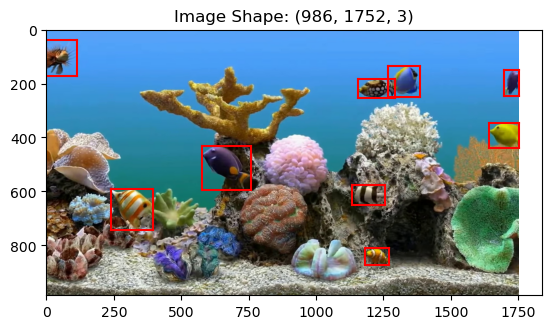

In [35]:
# load the image
image = Image.open(os.path.join(working_dir,'model','val','images',first_val_img)).convert('RGB')

# plot the figure
fig = plt.figure()
plt.imshow(image)

# add the bounding boxes:
for ll in range(np.shape(boxes)[0]):
    extent = np.copy(boxes[ll,:])
    plot_bounding_box(plt.gca(), image_width, image_height, extent)

plt.title('Image Shape: '+str(np.shape(image_array)))
plt.show()

Depending on how many epochs you train for, you may or may not have some satisfactory results in the figure above. For example, if you only trained for 5 epochs, then you may be missing some fish and you may be identifying some parts of the coral as fish. However, if you trained for many epochs (e.g. 100+), then your model should be performing quite well!

### Time Series Analysis

Now that we've got a working model, we have to remember why it is we started - our science question perhaps. Let's use our model to make predictions for how many fish are observed in each image through our video:

In [36]:
# compute results for all of the images in the video
# point the model to the folder (not a single image as shown above)
results = model.predict(os.path.join(working_dir,'images'), verbose=False)

In [37]:
# make a list of fish counts - the number of bounding boxes in each frame
fish_counts = []
for r in results:
    bbox = r.boxes.xywhn
    fish_counts.append(bbox.shape[0])

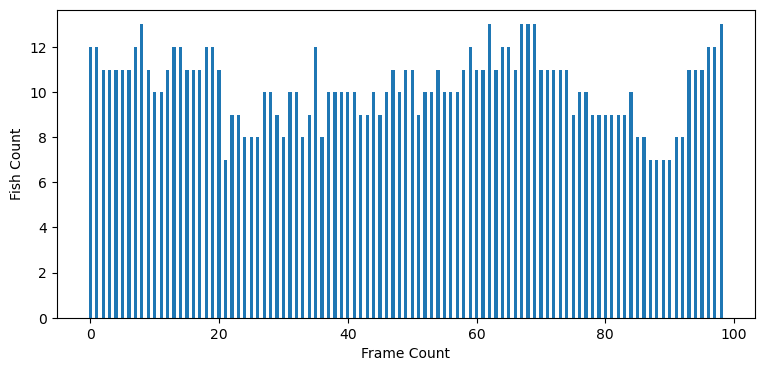

In [38]:
plt.figure(figsize=(9,4))
plt.bar(np.arange(len(fish_counts)),fish_counts, width=0.5)
plt.xlabel('Frame Count')
plt.ylabel('Fish Count')
plt.show()

Using this information, we could then start to explore conditions that lead to higher fish counts and other fun science info. However, we don't know much about our toy aquarium in this case, so let's stop here.

### Key Takeaways

1. YOLO performs object detection in a single forward pass, predicting bounding boxes and class labels simultaneously.
2. Fine-tuning a pre-trained model reduces the amount of data and training time required to create an object detection model.
3. After models have been fined tuned, they can be used for scientific tasks such estimating fish counts over time from video footage.